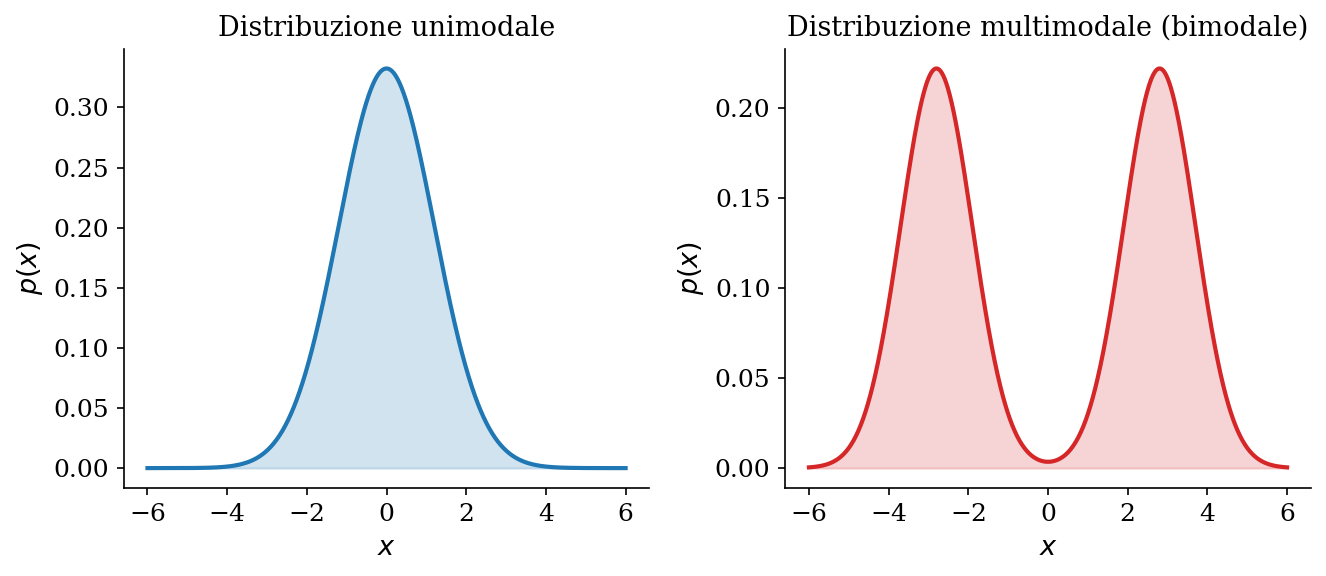

In [2]:
"""
Script per generare due distribuzioni di probabilità da inserire nella tesi:
  - una distribuzione UNIMODALE (gaussiana, es. potenziale armonico / pozzo singolo)
  - una distribuzione MULTIMODALE (bimodale, es. potenziale a doppio pozzo)

Output: figura PNG (e opzionalmente PDF) ad alta risoluzione, pronta per LaTeX.
"""

import numpy as np
import matplotlib.pyplot as plt

# --- Stile "da tesi" (font serif, dimensioni leggibili) -----------------
plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "figure.dpi": 150,
})

x = np.linspace(-6, 6, 1000)

# -------------------------------------------------------------------
# 1) Distribuzione UNIMODALE: gaussiana centrata in 0
#    (rappresenta ad es. la distribuzione di Boltzmann per un
#    potenziale armonico / pozzo singolo)
# -------------------------------------------------------------------
mu, sigma = 0.0, 1.2
uni = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
uni /= np.trapezoid(uni, x)  # normalizzazione

# -------------------------------------------------------------------
# 2) Distribuzione MULTIMODALE: somma di due gaussiane (bimodale),
#    che imita la distribuzione di Boltzmann per un doppio pozzo
#    simmetrico, con due minimi a +-a e una barriera centrale
# -------------------------------------------------------------------
a = 2.8          # posizione dei due minimi
sigma2 = 0.9     # larghezza di ciascun modo
w = 0.5          # peso relativo (simmetrico -> 0.5 e 0.5)

multi = (
    w * np.exp(-0.5 * ((x - a) / sigma2) ** 2)
    + (1 - w) * np.exp(-0.5 * ((x + a) / sigma2) ** 2)
)
multi /= np.trapezoid(multi, x)  # normalizzazione

# -------------------------------------------------------------------
# Plot affiancato
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=False)

axes[0].plot(x, uni, color="#1f77b4", lw=2)
axes[0].fill_between(x, uni, color="#1f77b4", alpha=0.2)
axes[0].set_title("Distribuzione unimodale")
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$p(x)$")

axes[1].plot(x, multi, color="#d62728", lw=2)
axes[1].fill_between(x, multi, color="#d62728", alpha=0.2)
axes[1].set_title("Distribuzione multimodale (bimodale)")
axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$p(x)$")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()